# ConvNeXt-Tiny Grad-CAM Localization Evaluation

This notebook evaluates Grad-CAM localization for the final ConvNeXt-Tiny model using the NIH ChestX-ray14 bounding-box subset
Threshold tuning is performed on loc_tune and final localization is reported on loc_report

## 1. Setup

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
import torch.nn as nn

from torchvision import transforms
from torchvision.models import convnext_tiny
from PIL import Image

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cu128
CUDA available: True
Device: cuda
GPU: Tesla T4


In [2]:
LABELS = [
    "Atelectasis",
    "Consolidation",
    "Infiltration",
    "Pneumothorax",
    "Edema",
    "Emphysema",
    "Fibrosis",
    "Effusion",
    "Pneumonia",
    "Pleural_Thickening",
    "Cardiomegaly",
    "Nodule",
    "Mass",
    "Hernia"
]

NUM_CLASSES = len(LABELS)

CHECKPOINT_PATH = (
    "/kaggle/input/notebooks/rabehalmutire/"
    "01-convnext-training/convnext_tiny_320_best.pth"
)

SPLITS_ROOT = (
    "/kaggle/input/datasets/iwmm10/"
    "chestxray-capstone-splits/capstone_splits/splits"
)

LOC_TUNE_PATH = os.path.join(SPLITS_ROOT, "loc_tune.csv")
LOC_REPORT_PATH = os.path.join(SPLITS_ROOT, "loc_report.csv")

BBOX_PATH = (
    "/kaggle/input/datasets/iwmm10/"
    "chestxray-capstone-splits/capstone_splits/BBox_List_2017.csv"
)

print("Number of model classes:", NUM_CLASSES)

Number of model classes: 14


## 2. Image Paths and Inference Preprocessing

In [3]:
NIH_DATA_ROOT = "/kaggle/input/datasets/nih-chest-xrays/data"

IMAGE_DIRS = [
    os.path.join(
        NIH_DATA_ROOT,
        f"images_{i:03d}",
        "images"
    )
    for i in range(1, 13)
]

image_path_map = {}

for directory in IMAGE_DIRS:
    for filename in os.listdir(directory):
        if filename.lower().endswith(".png"):
            image_path_map[filename] = os.path.join(directory, filename)

print("Total indexed images:", len(image_path_map))

Total indexed images: 112120


In [4]:
IMAGE_SIZE = 320
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

print("Inference transform ready:", IMAGE_SIZE, "x", IMAGE_SIZE)

Inference transform ready: 320 x 320


## 3. Localization Splits and Bounding Boxes

In [6]:
loc_tune_df = pd.read_csv(LOC_TUNE_PATH)
loc_report_df = pd.read_csv(LOC_REPORT_PATH)
bbox_df = pd.read_csv(BBOX_PATH)

# Match the annotation class name to the model label.
bbox_df["Finding Label"] = bbox_df["Finding Label"].replace({
    "Infiltrate": "Infiltration"
})

print("loc_tune:", loc_tune_df.shape)
print("loc_report:", loc_report_df.shape)
print("Bounding-box annotations:", bbox_df.shape)
print("Annotated classes:", sorted(bbox_df["Finding Label"].unique()))

loc_tune: (2606, 26)
loc_report: (2576, 26)
Bounding-box annotations: (984, 9)
Annotated classes: ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax']


## 4. Load Final ConvNeXt-Tiny Model

In [5]:
# The checkpoint contains the final trained weights, so no separate
# ImageNet weight download is needed here.
model = convnext_tiny(weights=None)

in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, NUM_CLASSES)

model = model.to(device)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Final trained model loaded successfully")
print("Classifier input features:", in_features)
print("Output classes:", NUM_CLASSES)

Final trained model loaded successfully
Classifier input features: 768
Output classes: 14


## 5. Grad-CAM Setup

In [7]:
# Final depthwise convolution in the last ConvNeXt block.
target_layer = model.features[-1][-1].block[0]

activations = {}
gradients = {}

def forward_hook(module, inputs, output):
    activations["value"] = output

def backward_hook(module, grad_input, grad_output):
    gradients["value"] = grad_output[0]

forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

print("Grad-CAM target layer:", target_layer)
print("Grad-CAM hooks registered")

Grad-CAM target layer: Conv2d(768, 768, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=768)
Grad-CAM hooks registered


In [8]:
# Grad-CAM localization utilities

def generate_gradcam(image, target_class):
    input_tensor = eval_transform(image).unsqueeze(0).to(device)

    model.zero_grad()

    logits = model(input_tensor)
    score = logits[0, target_class]
    score.backward()

    acts = activations["value"]
    grads = gradients["value"]

    weights = grads.mean(dim=(2, 3), keepdim=True)

    cam = (weights * acts).sum(dim=1)
    cam = torch.relu(cam)

    cam = cam[0]
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    return cam.detach().cpu().numpy()


def heatmap_to_bbox(gradcam_map, image_size, threshold):
    cam_img = Image.fromarray(np.uint8(gradcam_map * 255))
    cam_img = cam_img.resize(image_size)

    cam_resized = np.array(cam_img) / 255.0

    binary_mask = cam_resized >= threshold

    ys, xs = np.where(binary_mask)

    if len(xs) == 0 or len(ys) == 0:
        return None

    x = xs.min()
    y = ys.min()
    w = xs.max() - xs.min() + 1
    h = ys.max() - ys.min() + 1

    return (x, y, w, h)


def calculate_iobb(pred_bbox, gt_bbox):
    if pred_bbox is None:
        return 0.0

    pred_x, pred_y, pred_w, pred_h = pred_bbox
    gt_x, gt_y, gt_w, gt_h = gt_bbox

    pred_x2 = pred_x + pred_w
    pred_y2 = pred_y + pred_h

    gt_x2 = gt_x + gt_w
    gt_y2 = gt_y + gt_h

    inter_x1 = max(pred_x, gt_x)
    inter_y1 = max(pred_y, gt_y)
    inter_x2 = min(pred_x2, gt_x2)
    inter_y2 = min(pred_y2, gt_y2)

    inter_w = max(0, inter_x2 - inter_x1)
    inter_h = max(0, inter_y2 - inter_y1)

    intersection_area = inter_w * inter_h
    pred_area = pred_w * pred_h

    return intersection_area / pred_area if pred_area > 0 else 0.0


print("Localization functions ready")

Localization functions ready


## 6. Grad-CAM Sanity Check

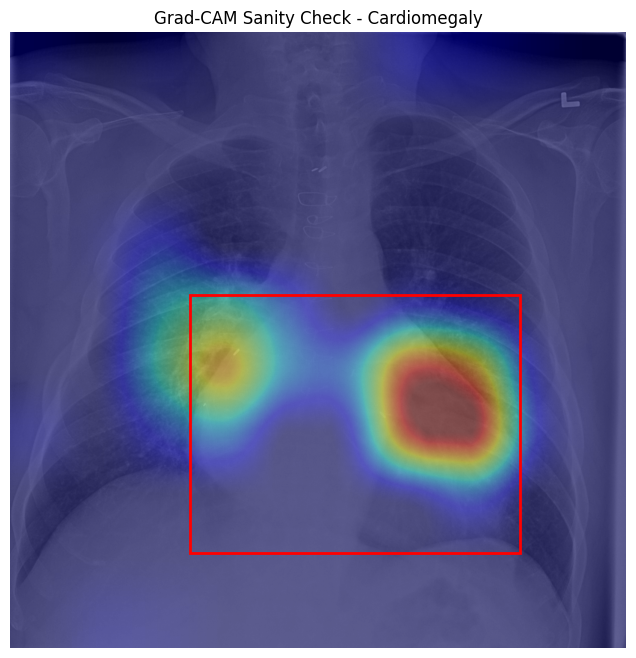

In [9]:
# Use one annotated Cardiomegaly case from loc_tune to verify alignment.
loc_tune_with_bbox = loc_tune_df[
    loc_tune_df["Image Index"].isin(bbox_df["Image Index"])
]

cardio_bbox_images = loc_tune_with_bbox[
    loc_tune_with_bbox["Image Index"].isin(
        bbox_df.loc[
            bbox_df["Finding Label"] == "Cardiomegaly",
            "Image Index"
        ]
    )
]

sample_row = cardio_bbox_images.iloc[0]
image_name = sample_row["Image Index"]

image = Image.open(image_path_map[image_name]).convert("RGB")

target_class = LABELS.index("Cardiomegaly")
gradcam_map = generate_gradcam(image, target_class)

sample_bbox = bbox_df[
    (bbox_df["Image Index"] == image_name) &
    (bbox_df["Finding Label"] == "Cardiomegaly")
]

cam_img = Image.fromarray(np.uint8(gradcam_map * 255))
cam_img = cam_img.resize(image.size)
cam_resized = np.array(cam_img) / 255.0

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(np.array(image), cmap="gray")
ax.imshow(cam_resized, cmap="jet", alpha=0.4)

for _, gt in sample_bbox.iterrows():
    rect = patches.Rectangle(
        (gt["Bbox [x"], gt["y"]),
        gt["w"],
        gt["h]"],
        linewidth=2,
        edgecolor="red",
        facecolor="none",
        label="Ground Truth"
    )
    ax.add_patch(rect)

ax.set_title("Grad-CAM Sanity Check - Cardiomegaly")
ax.axis("off")
plt.show()

The sanity check shows that the Grad-CAM heatmap is aligned with the X-ray

## 7. Tune Heatmap Threshold on `loc_tune`

In [10]:
# Tune Grad-CAM heatmap threshold on loc_tune

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9]

loc_tune_names = set(loc_tune_df["Image Index"])

tune_bbox_df = bbox_df[
    bbox_df["Image Index"].isin(loc_tune_names)
].copy()

# Evaluate each unique image-pathology pair
pairs = tune_bbox_df[
    ["Image Index", "Finding Label"]
].drop_duplicates()

results = []

for i, (_, row) in enumerate(pairs.iterrows(), start=1):

    image_name = row["Image Index"]
    finding = row["Finding Label"]

    if finding not in LABELS or image_name not in image_path_map:
        continue

    image_path = image_path_map[image_name]
    image = Image.open(image_path).convert("RGB")

    target_class = LABELS.index(finding)

    # Generate Grad-CAM once for this image and class
    cam = generate_gradcam(image, target_class)

    # Get all ground-truth boxes for this image and class
    gt_rows = tune_bbox_df[
        (tune_bbox_df["Image Index"] == image_name) &
        (tune_bbox_df["Finding Label"] == finding)
    ]

    gt_boxes = [
        (r["Bbox [x"], r["y"], r["w"], r["h]"])
        for _, r in gt_rows.iterrows()
    ]

    for threshold in thresholds:

        pred_bbox = heatmap_to_bbox(
            cam,
            image.size,
            threshold
        )

        # Use the best overlap if multiple GT boxes exist
        iobb_values = [
            calculate_iobb(pred_bbox, gt_bbox)
            for gt_bbox in gt_boxes
        ]

        best_iobb = max(iobb_values) if iobb_values else 0.0

        results.append({
            "Image": image_name,
            "Class": finding,
            "Heatmap Threshold": threshold,
            "IoBB": best_iobb
        })

    if i % 25 == 0:
        print(f"Processed {i}/{len(pairs)} image-class pairs")

tune_results = pd.DataFrame(results)

threshold_summary = (
    tune_results
    .groupby("Heatmap Threshold")
    .agg(
        Mean_IoBB=("IoBB", "mean"),
        IoBB_0_1=("IoBB", lambda x: (x >= 0.1).mean()),
        IoBB_0_25=("IoBB", lambda x: (x >= 0.25).mean()),
        IoBB_0_5=("IoBB", lambda x: (x >= 0.5).mean())
    )
    .reset_index()
)

display(threshold_summary)

Processed 25/376 image-class pairs
Processed 50/376 image-class pairs
Processed 75/376 image-class pairs
Processed 100/376 image-class pairs
Processed 125/376 image-class pairs
Processed 150/376 image-class pairs
Processed 175/376 image-class pairs
Processed 200/376 image-class pairs
Processed 225/376 image-class pairs
Processed 250/376 image-class pairs
Processed 275/376 image-class pairs
Processed 300/376 image-class pairs
Processed 325/376 image-class pairs
Processed 350/376 image-class pairs
Processed 375/376 image-class pairs


,Heatmap Threshold,Mean_IoBB,IoBB_0_1,IoBB_0_25,IoBB_0_5
0,0.30,0.194489,0.457447,0.255319,0.127660
1,0.40,0.239977,0.518617,0.327128,0.178191
2,0.50,0.291729,0.553191,0.367021,0.260638
3,0.60,0.331080,0.582447,0.414894,0.311170
4,0.70,0.364947,0.585106,0.454787,0.348404
5,0.75,0.379590,0.571809,0.468085,0.369681
6,0.80,0.387506,0.569149,0.473404,0.382979
7,0.85,0.400960,0.566489,0.473404,0.398936
8,0.90,0.410896,0.553191,0.470745,0.412234


In [11]:
# Frozen after loc_tune tuning and before loc_report evaluation.
FINAL_HEATMAP_THRESHOLD = 0.90

print("Final heatmap threshold:", FINAL_HEATMAP_THRESHOLD)

Final heatmap threshold: 0.9


The heatmap threshold is selected using `loc_tune` only,It is then frozen before evaluating the held-out `loc_report` split

## 8. Final Localization Evaluation on `loc_report`

In [12]:
# Final Grad-CAM localization evaluation on loc_report

LOC_REPORT_PATH = "/kaggle/input/datasets/iwmm10/chestxray-capstone-splits/capstone_splits/splits/loc_report.csv"

loc_report_df = pd.read_csv(LOC_REPORT_PATH)

loc_report_names = set(loc_report_df["Image Index"])

report_bbox_df = bbox_df[
    bbox_df["Image Index"].isin(loc_report_names)
].copy()

report_pairs = report_bbox_df[
    ["Image Index", "Finding Label"]
].drop_duplicates()

report_results = []

for i, (_, row) in enumerate(report_pairs.iterrows(), start=1):

    image_name = row["Image Index"]
    finding = row["Finding Label"]

    if finding not in LABELS or image_name not in image_path_map:
        continue

    image_path = image_path_map[image_name]
    image = Image.open(image_path).convert("RGB")

    target_class = LABELS.index(finding)

    cam = generate_gradcam(image, target_class)

    pred_bbox = heatmap_to_bbox(
        cam,
        image.size,
        FINAL_HEATMAP_THRESHOLD
    )

    gt_rows = report_bbox_df[
        (report_bbox_df["Image Index"] == image_name) &
        (report_bbox_df["Finding Label"] == finding)
    ]

    gt_boxes = [
        (r["Bbox [x"], r["y"], r["w"], r["h]"])
        for _, r in gt_rows.iterrows()
    ]

    iobb_values = [
        calculate_iobb(pred_bbox, gt_bbox)
        for gt_bbox in gt_boxes
    ]

    best_iobb = max(iobb_values) if iobb_values else 0.0

    report_results.append({
        "Image": image_name,
        "Class": finding,
        "IoBB": best_iobb
    })

    if i % 25 == 0:
        print(f"Processed {i}/{len(report_pairs)} image-class pairs")

report_results_df = pd.DataFrame(report_results)

final_summary = pd.DataFrame({
    "Mean IoBB": [report_results_df["IoBB"].mean()],
    "IoBB >= 0.1": [(report_results_df["IoBB"] >= 0.1).mean()],
    "IoBB >= 0.25": [(report_results_df["IoBB"] >= 0.25).mean()],
    "IoBB >= 0.5": [(report_results_df["IoBB"] >= 0.5).mean()]
})

display(final_summary)

Processed 25/373 image-class pairs
Processed 50/373 image-class pairs
Processed 75/373 image-class pairs
Processed 100/373 image-class pairs
Processed 125/373 image-class pairs
Processed 150/373 image-class pairs
Processed 175/373 image-class pairs
Processed 200/373 image-class pairs
Processed 225/373 image-class pairs
Processed 250/373 image-class pairs
Processed 275/373 image-class pairs
Processed 300/373 image-class pairs
Processed 325/373 image-class pairs
Processed 350/373 image-class pairs


,Mean IoBB,IoBB >= 0.1,IoBB >= 0.25,IoBB >= 0.5
0,0.416708,0.565684,0.482574,0.394102


## 9. Class-wise Localization Results

In [13]:
# Class-wise localization results

class_summary = (
    report_results_df
    .groupby("Class")
    .agg(
        Images=("Image", "count"),
        Mean_IoBB=("IoBB", "mean"),
        IoBB_0_1=("IoBB", lambda x: (x >= 0.1).mean()),
        IoBB_0_25=("IoBB", lambda x: (x >= 0.25).mean()),
        IoBB_0_5=("IoBB", lambda x: (x >= 0.5).mean())
    )
    .reset_index()
    .sort_values("Mean_IoBB", ascending=False)
)

display(class_summary)

,Class,Images,Mean_IoBB,IoBB_0_1,IoBB_0_25,IoBB_0_5
1,Cardiomegaly,81,0.886406,0.950617,0.938272,0.888889
6,Pneumonia,53,0.440763,0.584906,0.509434,0.415094
2,Effusion,44,0.423762,0.636364,0.545455,0.409091
4,Mass,30,0.316794,0.500000,0.433333,0.300000
3,Infiltration,41,0.287704,0.463415,0.341463,0.243902
0,Atelectasis,57,0.256627,0.456140,0.315789,0.228070
7,Pneumothorax,33,0.105653,0.212121,0.121212,0.090909
5,Nodule,34,0.065096,0.235294,0.117647,0.000000


## 10. Representative Grad-CAM Examples

In [14]:
# Select representative examples close to each class mean IoBB

example_classes = ["Cardiomegaly", "Effusion", "Nodule"]

representative_examples = []

for class_name in example_classes:
    class_rows = report_results_df[
        report_results_df["Class"] == class_name
    ].copy()

    class_mean = class_rows["IoBB"].mean()

    class_rows["Distance_to_Mean"] = (
        class_rows["IoBB"] - class_mean
    ).abs()

    representative_examples.append(
        class_rows.sort_values("Distance_to_Mean").iloc[0]
    )

representative_examples_df = pd.DataFrame(
    representative_examples
)

display(representative_examples_df)

,Image,Class,IoBB,Distance_to_Mean
85,00014706_007.png,Cardiomegaly,0.916202,0.029795
172,00028974_016.png,Effusion,0.419026,0.004736
265,00015141_002.png,Nodule,0.059788,0.005308


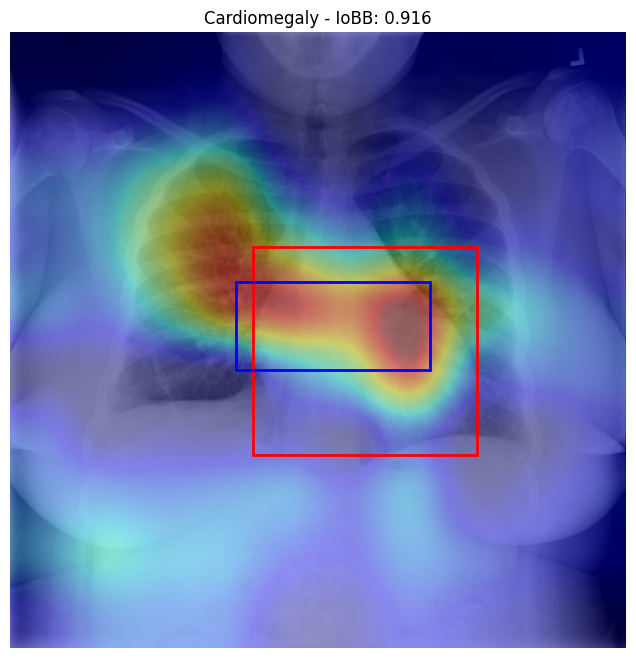

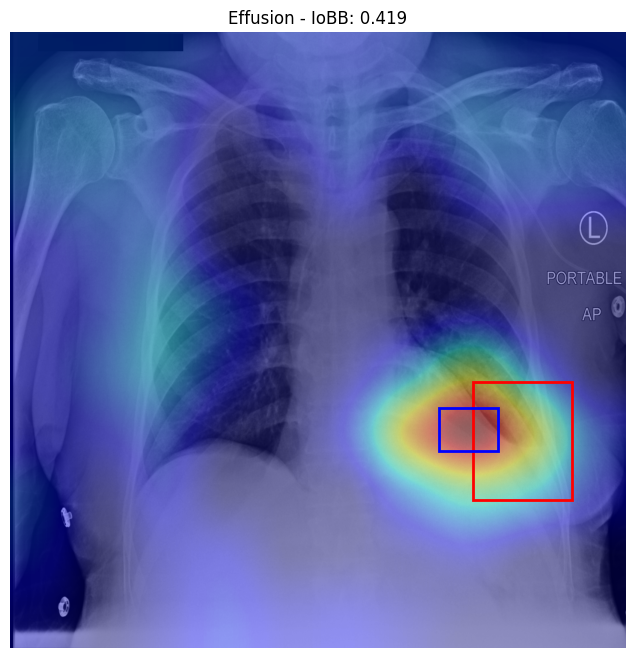

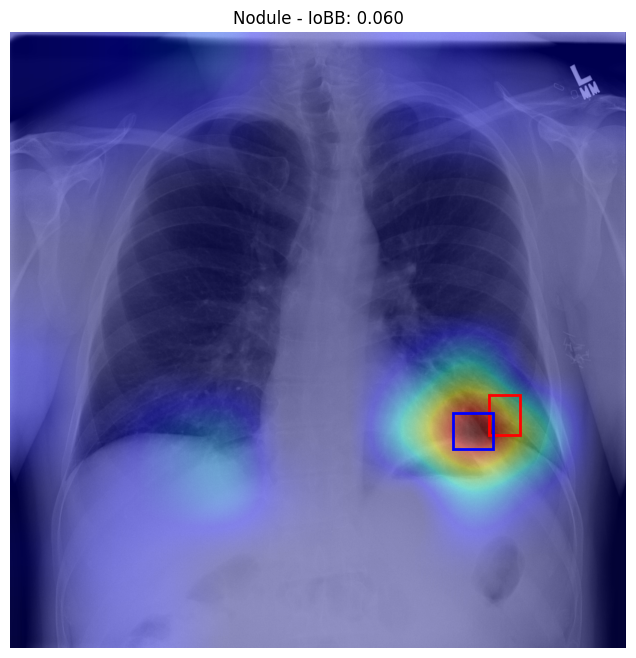

In [15]:
# Visualize selected Grad-CAM examples

for _, row in representative_examples_df.iterrows():

    image_name = row["Image"]
    class_name = row["Class"]

    image = Image.open(image_path_map[image_name]).convert("RGB")

    target_class = LABELS.index(class_name)
    cam = generate_gradcam(image, target_class)

    pred_bbox = heatmap_to_bbox(
        cam,
        image.size,
        FINAL_HEATMAP_THRESHOLD
    )

    cam_img = Image.fromarray(np.uint8(cam * 255))
    cam_img = cam_img.resize(image.size)
    cam_resized = np.array(cam_img) / 255.0

    gt_rows = report_bbox_df[
        (report_bbox_df["Image Index"] == image_name) &
        (report_bbox_df["Finding Label"] == class_name)
    ]

    fig, ax = plt.subplots(figsize=(8, 8))

    ax.imshow(np.array(image), cmap="gray")
    ax.imshow(cam_resized, cmap="jet", alpha=0.4)

    # Ground-truth boxes
    for _, gt in gt_rows.iterrows():
        rect = patches.Rectangle(
            (gt["Bbox [x"], gt["y"]),
            gt["w"],
            gt["h]"],
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )
        ax.add_patch(rect)

    # Grad-CAM predicted box
    if pred_bbox is not None:
        px, py, pw, ph = pred_bbox

        pred_rect = patches.Rectangle(
            (px, py),
            pw,
            ph,
            linewidth=2,
            edgecolor="blue",
            facecolor="none"
        )
        ax.add_patch(pred_rect)

    ax.set_title(
        f"{class_name} - IoBB: {row['IoBB']:.3f}"
    )

    ax.axis("off")
    plt.show()

## 11. Summary

The final Grad-CAM localization pipeline uses the final ConvNeXt-Tiny 320×320 BCE checkpoint and the same ImageNet-normalized preprocessing used for inference

- Heatmap threshold tuning is performed on `loc_tune`
- The selected heatmap threshold is **0.90**
- Final localization performance is evaluated once on `loc_report`
- IoBB is reported overall and by pathology for the eight bounding-box annotated classes
- Representative examples include strong, moderate, and weak localization cases to show realistic model behavior

The Grad-CAM results are intended for research and educational explainability and should not be interpreted as clinically validated lesion localization